[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aangelopoulos/conformal-prediction/blob/main/notebooks/meps-cqr.ipynb)

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns
!pip install -U --no-cache-dir gdown --pre

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.1
    Uninstalling gdown-5.2.1:
      Successfully uninstalled gdown-5.2.1


In [2]:
# Load cached data
# download the data, extract it, remove the compressed file if not data exists
if not os.path.exists('../data'):
    os.system('gdown 1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK -O ../data.tar.gz')
    os.system('tar -xf ../data.tar.gz -C ../')
    os.system('rm ../data.tar.gz')

data = np.load('../data/meps/meps-gbr.npz')
X, labels, upper, lower = data['X'], data['y'], data['upper'], data['lower']
# Load regression dataset: each row: (Xi, Yi, lower_i, upper_i)
# X → input features
# labels → true output values Y
# upper → model-predicted upper quantile t^1−α/2​(Xi​)
# lower → model-predicted lower quantile t^α/2​(Xi​)
# we dont know what quantile is this, but if we later get alpha = 0.1, then we can guess these are 0.05 (5%) and 0.95 (95%) quantile

In [3]:
# Problem setup
n=1000 # number of calibration points
alpha = 0.1 # 1-alpha is the desired coverage

In [4]:
# Split the softmax scores into calibration and validation sets (save the shuffling)
idx = np.array([1] * n + [0] * (labels.shape[0]-n)) > 0 # data are randonmly splitted: True → calibration, False → validation
np.random.shuffle(idx)
cal_labels, val_labels = labels[idx], labels[~idx]  # true Y values for calibration and validaiton
cal_upper, val_upper = upper[idx], upper[~idx] # upper and lower quantile predictions for calibration and validaiton
cal_lower, val_lower = lower[idx], lower[~idx]
val_X = X[~idx] # validation features, used later for plotting by cancer severity

### Conformal prediction happens here

In [5]:
# Get scores. cal_upper.shape[0] == cal_lower.shape[0] == n
cal_scores = np.maximum(cal_labels-cal_upper, cal_lower-cal_labels) # s(x, y)= max {tˆα/2(x) − y, y − tˆ1−α/2(x)}
# Get the score quantile
qhat = np.quantile(cal_scores, np.ceil((n+1)*(1-alpha))/n, interpolation='higher') # compute the qˆ = (n+1)(1−α)/ n
# Deploy (output=lower and upper adjusted quantiles)
prediction_sets = [val_lower - qhat, val_upper + qhat] # prediciton set C(x) = [tˆα/2(x) − qˆ, tˆ1−α/2(x) + qˆ]

In [6]:
# Calculate empirical coverage (before and after calibration)
prediction_sets_uncalibrated = [val_lower, val_upper]  # model's original prediciton set before before conformal adjustment.
# covergae before: (val_labels >= lower) & (val_labels <= upper): Is the true value inside the interval? if so True, else False, then take the mean
empirical_coverage_uncalibrated = ((val_labels >= prediction_sets_uncalibrated[0]) & (val_labels <= prediction_sets_uncalibrated[1])).mean()
print(f"The empirical coverage before calibration is: {empirical_coverage_uncalibrated}")
# Coverrage after: the same way
empirical_coverage = ((val_labels >= prediction_sets[0]) & (val_labels <= prediction_sets[1])).mean()
print(f"The empirical coverage after calibration is: {empirical_coverage}")

The empirical coverage before calibration is: 0.737414768605832
The empirical coverage after calibration is: 0.9315247352386479


lower_uncal:  [np.float64(0.41395307192511277), np.float64(0.4874939053736755), np.float64(0.5629821445157297), np.float64(0.6797817884461625), np.float64(0.7584803845326332)]
lower_cal:  [np.float64(-0.08884615185754537), np.float64(-0.04145630934952603), np.float64(0.0071884448148635495), np.float64(0.08245434093402329), np.float64(0.13316785476370585)]
upper_uncal:  [np.float64(15.185101064718268), np.float64(17.3087342405204), np.float64(19.539958706796057), np.float64(28.8150406731031), np.float64(30.186217254415986)]
upper_cal:  [np.float64(24.116475572738672), np.float64(27.41198670808544), np.float64(30.874460904596422), np.float64(45.26778280665863), np.float64(47.39561154079796)]


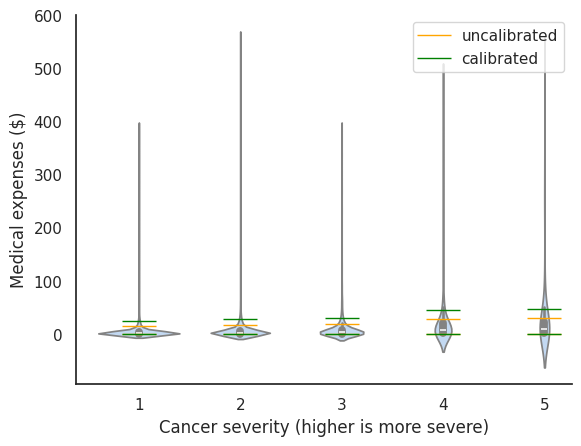

In [9]:
# Plot results stratifying across cancer severity (one of many covariates)
cancer_vecs = val_X[:,40:45] # This selects columns 40 to 44 from the validation features.
# Convert to one-hot style binary indicators: This converts the 5 binary columns into a single cancer severity number: 1,2,3,4,5
# For each cancer-related feature column:
# find the max value
# mark rows equal to that max as 1
# everything else as 0
# This turns those columns into binary indicators.
for col in range(cancer_vecs.shape[1]):
    one_val = cancer_vecs[:,col].max()
    cancer_vecs[:,col] = (cancer_vecs[:,col] == one_val).astype(int)
cancer_dx = cancer_vecs.dot(np.arange(5)+1).astype(int)

# Trim missing labels: This removes rows where no cancer severity label was assigned (cancer_dx = 0).So now only patients with severity 1–5 remain.
val_labels_trimmed = val_labels[cancer_dx > 0]
val_lower_trimmed = val_lower[cancer_dx > 0]
val_upper_trimmed = val_upper[cancer_dx > 0]
cancer_dx_trimmed = cancer_dx[cancer_dx > 0]
valid_cancer_dx = np.arange(5)+1

# Compute average lower/upper interval bounds by severity: without and with calibraiton
# Why np.e**(...) - 1?
# That means:e^z−1
# This suggests the medical expenses were stored on a log scale earlier.
# So this transforms predictions back to the original dollar scale.
lower_uncal = [(np.e**(val_lower_trimmed[cancer_dx_trimmed == dx]) - 1).mean() for dx in valid_cancer_dx]
lower_cal = [(np.e**(val_lower_trimmed[cancer_dx_trimmed == dx]-qhat) - 1).mean() for dx in valid_cancer_dx]
upper_uncal = [(np.e**(val_upper_trimmed[cancer_dx_trimmed == dx]) - 1).mean() for dx in valid_cancer_dx]
upper_cal = [(np.e**(val_upper_trimmed[cancer_dx_trimmed == dx]+qhat) - 1).mean() for dx in valid_cancer_dx]
print("lower_uncal: ", lower_uncal)
print("lower_cal: ", lower_cal)
print("upper_uncal: ", upper_uncal)
print("upper_cal: ", upper_cal)



sns.set(style='white')
sns.set_palette('pastel')
plt.figure()
# This randomly shuffles the plotting order, so the violin plot does not depend on original row order.
plt_idx = np.random.choice(np.arange(val_labels_trimmed.shape[0]), size=(val_labels_trimmed.shape[0],), replace=False)
# This draws the distribution of actual medical expenses for each cancer severity group.
sns.violinplot(x=cancer_dx_trimmed[plt_idx], y=np.e**val_labels_trimmed[plt_idx]-1, color='#BBD9FA')
plt.plot(valid_cancer_dx-1, lower_uncal, marker='_', markersize='25', linewidth=0, color='orange', label='uncalibrated')
plt.plot(valid_cancer_dx-1, upper_uncal, marker='_', markersize='25', linewidth=0, color='orange')
plt.plot(valid_cancer_dx-1, lower_cal, marker='_', markersize='25', linewidth=0, color='green', label='calibrated')
plt.plot(valid_cancer_dx-1, upper_cal, marker='_', markersize='25', linewidth=0, color='green')
plt.legend(loc='upper right')
#plt.ylim(0,80)
plt.xlabel('Cancer severity (higher is more severe)')
plt.ylabel('Medical expenses ($)')
sns.despine(top=True,right=True)
plt.show()
# figure explanaiton
# 🔍 Height (vertical)
# Range of values
# bottom → low expenses
# top → high expenses

# 👉 Higher severity → taller violin → larger possible expenses

# 🔍 Width (horizontal thickness)
# Density (how many data points are there)
# wide → many data points there
# narrow → few data points

This method was first introduced in https://arxiv.org/abs/1905.03222.